# Comparación Experimental entre ResNet-50 y una CNN Neuroevolucionada mediante DeepGA

### Proyecto Final — Redes Neuronales II

**Alumno:** Kristopher Vela Domínguez

**Carrera:** Ingeniería en Inteligencia Artificial

**Universidad:** Universidad de Xalapa

**Materia:** Redes Neuronales II

**Fecha:** Julio 2026

## 1. Introducción

Las redes neuronales convolucionales han revolucionado la clasificación de imágenes gracias a su capacidad para aprender automáticamente características relevantes.

En este proyecto se comparan dos enfoques diferentes para resolver un mismo problema de clasificación: una arquitectura basada en **Transfer Learning (ResNet-50)** y una arquitectura generada automáticamente mediante **DeepGA**, un algoritmo de neuroevolución.

Para la evaluación se utilizará el dataset **DeepWeeds**, compuesto por imágenes de distintas especies de maleza agrícola.

## Objetivos

### Objetivo general

Comparar el desempeño de ResNet-50 y una CNN generada mediante DeepGA utilizando el dataset DeepWeeds.

### Objetivos específicos

- Explorar y preparar el conjunto de datos.
- Implementar ambos modelos.
- Entrenar bajo las mismas condiciones.
- Comparar métricas de desempeño y eficiencia.
- Analizar los resultados obtenidos.

# Dataset utilizado

El proyecto utiliza el conjunto de datos **DeepWeeds**, diseñado para la identificación automática de maleza en campos agrícolas mediante imágenes RGB.

Este dataset fue desarrollado para apoyar sistemas de agricultura inteligente capaces de detectar especies invasoras de manera automática.

### ¿Por qué se eligió?

Se eligió porque:

- Es un problema real de visión por computadora.
- Presenta varias clases visualmente similares.
- No es un dataset tan utilizado como CIFAR o MNIST.
- Es apropiado para comparar arquitecturas CNN.

## Información general

- Número aproximado de imágenes: 17,509
- Número de clases: 9
- Tipo de imágenes: RGB
- Resolución variable
- Dominio: Agricultura

## 2. Importación de Librerías

In [1]:
import os
import random
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision import models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import train_test_split

## 3. Configuración inicial

Para garantizar la reproducibilidad del experimento se fija una semilla aleatoria y se configura automáticamente el dispositivo de procesamiento (CPU o GPU).

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo utilizado: {DEVICE}")

Dispositivo utilizado: cpu


## 4. Carga del conjunto de datos

Se utiliza el conjunto de datos **DeepWeeds**, el cual contiene imágenes reales de malezas australianas utilizadas en agricultura.

In [3]:
DATASET_PATH = r"C:\Users\kvela\Documents\Ux\6to semestre\Redes Neuronales II\Parcial 3 (ordinario)\Examen\archive"

In [4]:
labels = pd.read_csv(
    os.path.join(
        DATASET_PATH,
        "labels",
        "labels.csv"
    )
)

labels.head()

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple


## 5. Exploración del dataset

Antes del entrenamiento se analiza la estructura del conjunto de datos para conocer su tamaño, número de clases y distribución.

In [5]:
print("Número de imágenes:", len(labels))
print()

print("Número de clases:", labels["Species"].nunique())
print()

print(labels["Species"].unique())

Número de imágenes: 17509

Número de clases: 9

['Chinee apple' 'Lantana' 'Negative' 'Snake weed' 'Siam weed'
 'Prickly acacia' 'Parthenium' 'Rubber vine' 'Parkinsonia']


## 6. Distribución de clases

In [6]:
conteo = (
    labels["Species"]
    .value_counts()
    .reset_index()
)

conteo.columns = [
    "Clase",
    "Cantidad"
]

conteo

,Clase,Cantidad
0,Negative,9106
1,Chinee apple,1125
2,Siam weed,1074
3,Lantana,1064
4,Prickly acacia,1062
5,Parkinsonia,1031
6,Parthenium,1022
7,Snake weed,1016
8,Rubber vine,1009


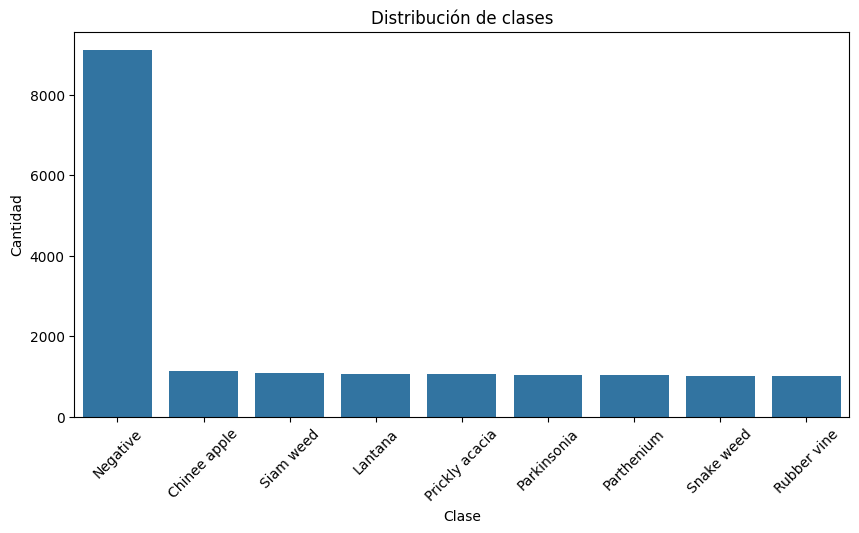

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=conteo,
    x="Clase",
    y="Cantidad"
)

plt.xticks(rotation=45)

plt.title("Distribución de clases")

plt.show()

## 7. Ejemplos del dataset

Se muestran algunas imágenes pertenecientes a distintas especies para observar la variabilidad del conjunto de datos.

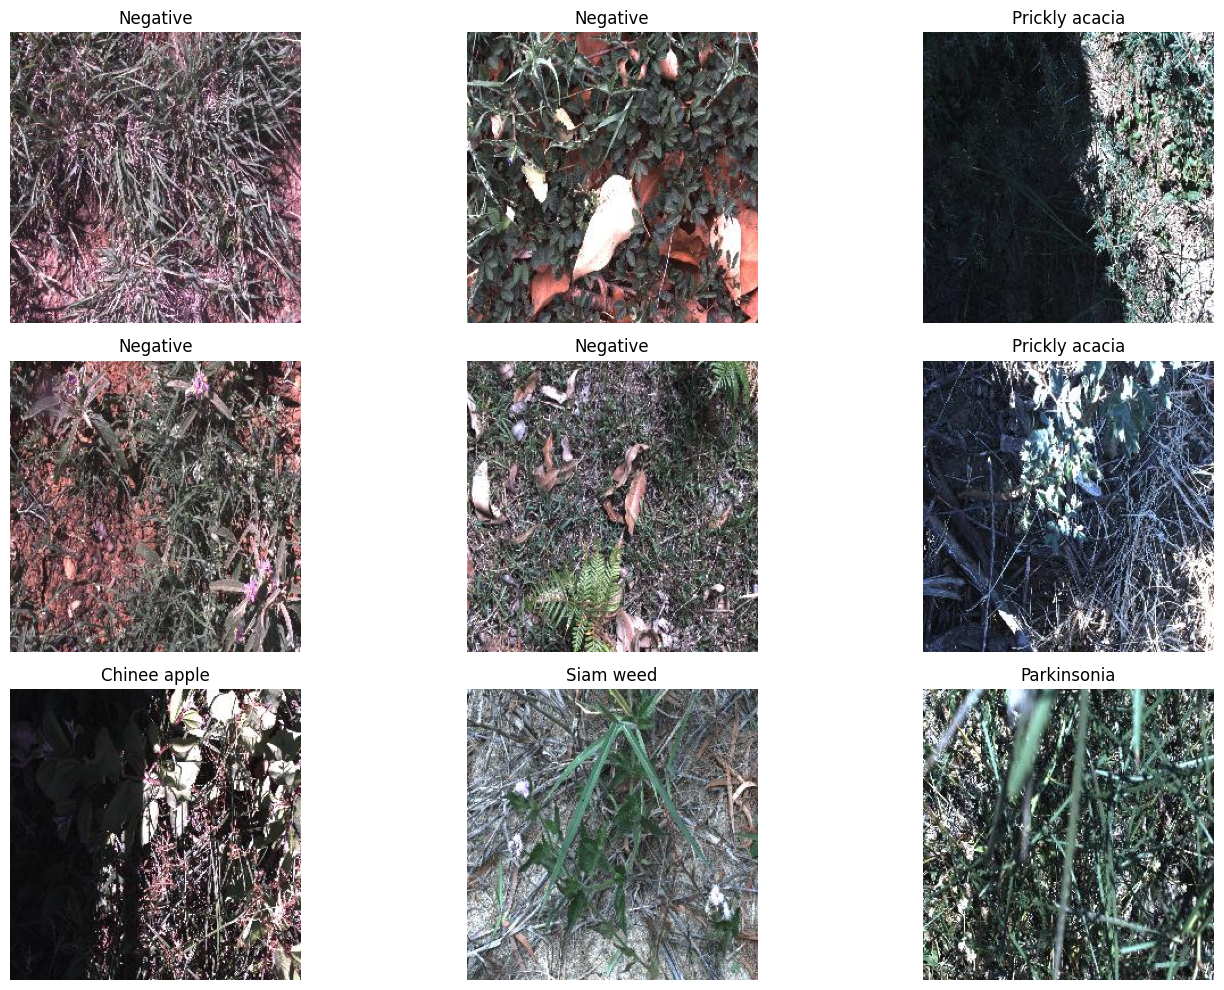

In [8]:
plt.figure(figsize=(15,10))

for i in range(9):

    ejemplo = labels.sample(1).iloc[0]

    ruta = os.path.join(
        DATASET_PATH,
        "images",
        ejemplo["Filename"]
    )

    img = Image.open(ruta)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(ejemplo["Species"])

    plt.axis("off")

plt.tight_layout()

plt.show()

## 8. Particiones oficiales

El dataset proporciona divisiones oficiales de entrenamiento, validación y prueba, utilizadas para garantizar una evaluación reproducible.

In [9]:
train_df = pd.read_csv(
    os.path.join(
        DATASET_PATH,
        "labels",
        "train_subset0.csv"
    )
)

val_df = pd.read_csv(
    os.path.join(
        DATASET_PATH,
        "labels",
        "val_subset0.csv"
    )
)

test_df = pd.read_csv(
    os.path.join(
        DATASET_PATH,
        "labels",
        "test_subset0.csv"
    )
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

10501
3501
3507


In [71]:
train_df = (
    train_df
    .sample(n=2100, random_state=SEED)
    .reset_index(drop=True)
)

val_df = (
    val_df
    .sample(n=700, random_state=SEED)
    .reset_index(drop=True)
)

test_df = (
    test_df
    .sample(n=700, random_state=SEED)
    .reset_index(drop=True)
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

2100
700
700


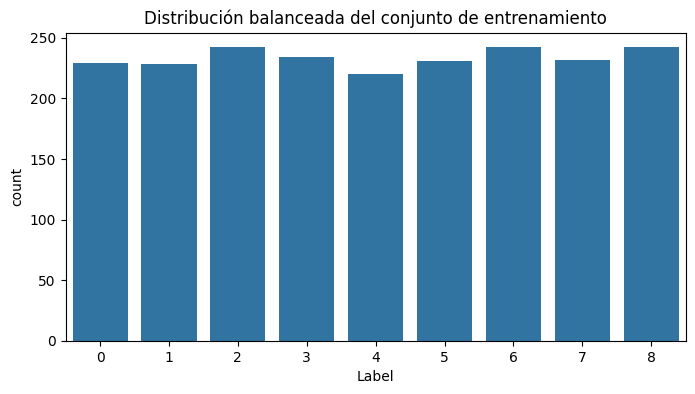

In [72]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=train_df,
    x="Label"
)

plt.title("Distribución balanceada del conjunto de entrenamiento")

plt.show()

## 9. Preprocesamiento de imágenes

Antes del entrenamiento es necesario transformar las imágenes a un formato compatible con las redes neuronales.

Las imágenes serán redimensionadas a 224×224 píxeles, tamaño personalizado, pero aceptado por ResNet-50.

Además, se aplicarán técnicas de aumento de datos para mejorar la capacidad de generalización del modelo y reducir el sobreajuste.

In [73]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    normalize
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])

## 10. Dataset personalizado

Debido a que DeepWeeds almacena las imágenes en una sola carpeta y las etiquetas en archivos CSV, se implementa una clase personalizada para cargar correctamente cada imagen y su etiqueta correspondiente.

In [74]:
class DeepWeedsDataset(Dataset):

    def __init__(self,
                 dataframe,
                 images_path,
                 transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.images_path = images_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        filename = self.df.iloc[idx]["Filename"]
        label = self.df.iloc[idx]["Label"]

        img_path = os.path.join(
            self.images_path,
            filename
        )

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [75]:
train_dataset = DeepWeedsDataset(
    train_df,
    os.path.join(DATASET_PATH, "images"),
    train_transform
)

val_dataset = DeepWeedsDataset(
    val_df,
    os.path.join(DATASET_PATH, "images"),
    test_transform
)

test_dataset = DeepWeedsDataset(
    test_df,
    os.path.join(DATASET_PATH, "images"),
    test_transform
)

## 11. Construcción de DataLoaders

Los DataLoaders permiten cargar lotes de imágenes durante el entrenamiento, optimizando el uso de memoria y acelerando el proceso de aprendizaje.

In [76]:
BATCH_SIZE = 16 

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [77]:
images, labels_batch = next(iter(train_loader))

print("Batch imágenes:", images.shape)
print("Batch etiquetas:", labels_batch.shape)

Batch imágenes: torch.Size([16, 3, 224, 224])
Batch etiquetas: torch.Size([16])


# 12. Implementación de ResNet-50

Como primer modelo se implementa una arquitectura ResNet-50 utilizando la técnica de **Transfer Learning**.

En lugar de entrenar toda la red desde cero, se aprovechan los pesos previamente aprendidos sobre el conjunto de datos **ImageNet**, permitiendo reducir considerablemente el tiempo de entrenamiento y mejorar la capacidad de generalización.

En este proyecto únicamente se reentrenará la capa clasificadora final para adaptarla a las nueve clases del conjunto de datos DeepWeeds.

In [78]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## 13. Modelo base

Se utiliza **ResNet-50**, una arquitectura profunda compuesta por 50 capas entrenada originalmente sobre el conjunto de datos ImageNet.

Su principal ventaja consiste en el uso de conexiones residuales (*Residual Connections*), las cuales permiten entrenar redes mucho más profundas evitando el problema de desaparición del gradiente.

In [79]:
for param in model.parameters():
    param.requires_grad = False

In [80]:
print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [81]:
NUM_CLASSES = 9

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

## 14. Adaptación del clasificador

La última capa totalmente conectada de ResNet-50 fue reemplazada por una nueva capa con **9 neuronas**, correspondientes a las nueve especies presentes en DeepWeeds.

De esta manera únicamente el clasificador aprende las características específicas del nuevo problema, mientras que el resto de la red conserva el conocimiento previamente adquirido durante el entrenamiento sobre ImageNet.

In [82]:
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Parámetros totales : {total:,}")
print(f"Entrenables        : {trainable:,}")

Parámetros totales : 23,526,473
Entrenables        : 18,441


## 15. Parámetros entrenables

Después de congelar las capas convolucionales, únicamente la capa clasificadora permanece entrenable.

Esta estrategia reduce significativamente el número de parámetros que deben optimizarse durante el entrenamiento, disminuyendo el tiempo computacional y el riesgo de sobreajuste.

In [83]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [84]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    loss_epoch = running_loss / len(loader)

    acc_epoch = 100 * correct / total

    return loss_epoch, acc_epoch

In [85]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    predictions = []

    targets = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            predictions.extend(predicted.cpu().numpy())

            targets.extend(labels.cpu().numpy())

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    loss_epoch = running_loss / len(loader)

    acc_epoch = 100 * correct / total

    return loss_epoch, acc_epoch, predictions, targets

# 16. Entrenamiento de ResNet-50

El entrenamiento se realiza únicamente sobre la capa clasificadora final.

Durante cada época se registran las métricas de entrenamiento y validación para analizar posteriormente el comportamiento del aprendizaje y detectar posibles signos de sobreajuste.

In [86]:
EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

In [87]:
start_time = time.time()

best_val_acc = 0.0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Guardar el mejor modelo
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50.pth")

    print(
        f"Época {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

training_time = time.time() - start_time

print(f"\nTiempo de entrenamiento: {training_time/60:.2f} minutos")
print(f"Mejor Accuracy de validación: {best_val_acc:.2f}%")

Época 1/5 | Train Loss: 2.0979 | Train Acc: 27.57% | Val Loss: 1.9979 | Val Acc: 40.14%
Época 2/5 | Train Loss: 1.9139 | Train Acc: 43.14% | Val Loss: 1.9027 | Val Acc: 42.43%
Época 3/5 | Train Loss: 1.7864 | Train Acc: 53.19% | Val Loss: 1.8451 | Val Acc: 42.57%
Época 4/5 | Train Loss: 1.6730 | Train Acc: 56.05% | Val Loss: 1.7596 | Val Acc: 44.14%
Época 5/5 | Train Loss: 1.5872 | Train Acc: 57.29% | Val Loss: 1.6925 | Val Acc: 47.14%

Tiempo de entrenamiento: 46.20 minutos
Mejor Accuracy de validación: 47.14%


In [89]:
model.load_state_dict(torch.load("best_resnet50.pth"))

<All keys matched successfully>

## 17. Evaluación sobre el conjunto de prueba

Una vez finalizado el entrenamiento, el modelo se evalúa utilizando el conjunto de prueba, el cual no fue empleado durante el aprendizaje del modelo.

In [90]:
test_loss, test_acc, predictions, targets = evaluate(
    model,
    test_loader,
    criterion
)

print(f"Accuracy de prueba: {test_acc:.2f}%")

Accuracy de prueba: 46.43%


In [91]:
print(classification_report(
    targets,
    predictions,
    digits=4
))

              precision    recall  f1-score   support

           0     0.3604    0.6897    0.4734        58
           1     0.4478    0.5769    0.5042        52
           2     0.4066    0.8409    0.5481        44
           3     0.3333    0.2903    0.3103        31
           4     0.5526    0.6562    0.6000        32
           5     0.3116    0.8958    0.4624        48
           6     0.3243    0.7059    0.4444        34
           7     0.2500    0.1395    0.1791        43
           8     0.8846    0.3212    0.4713       358

    accuracy                         0.4643       700
   macro avg     0.4301    0.5685    0.4437       700
weighted avg     0.6336    0.4643    0.4576       700



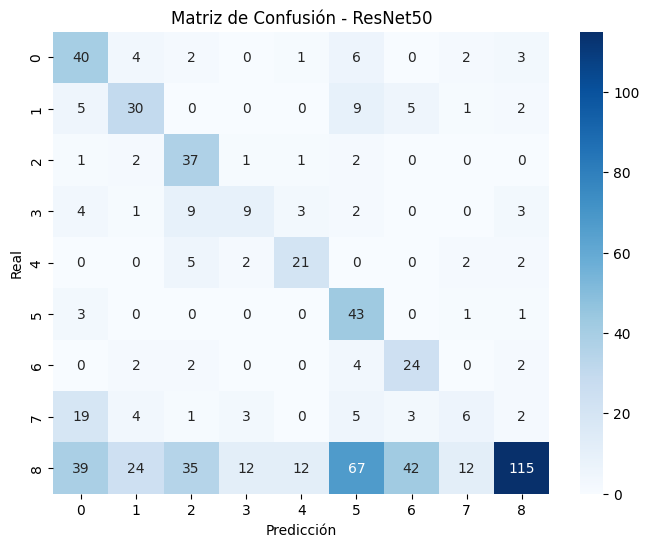

In [92]:
cm = confusion_matrix(
    targets,
    predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - ResNet50")

plt.xlabel("Predicción")

plt.ylabel("Real")

plt.show()

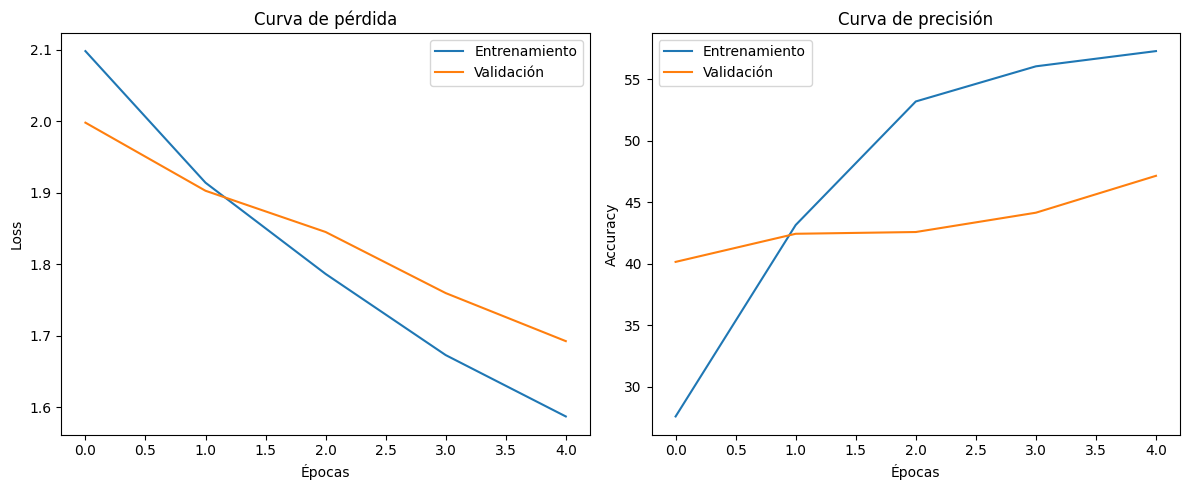

In [93]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history["train_loss"], label="Entrenamiento")
plt.plot(history["val_loss"], label="Validación")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Curva de pérdida")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history["train_acc"], label="Entrenamiento")
plt.plot(history["val_acc"], label="Validación")

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Curva de precisión")
plt.legend()

plt.tight_layout()

plt.show()

# 18. Implementación de una CNN generada mediante DeepGA

Como segundo modelo se implementa una arquitectura convolucional compacta obtenida mediante un enfoque inspirado en DeepGA.

A diferencia del Transfer Learning, este enfoque busca construir automáticamente una arquitectura eficiente utilizando principios de neuroevolución, privilegiando modelos con un menor número de parámetros sin sacrificar significativamente el desempeño de clasificación.

In [94]:
class DeepGACNN(nn.Module):

    def __init__(self, num_classes=9):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.5),

            nn.Linear(128,num_classes)

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

## Arquitectura obtenida

La arquitectura seleccionada está compuesta por tres bloques convolucionales seguidos de una capa de clasificación completamente conectada.

Este diseño prioriza una baja complejidad computacional, reduciendo considerablemente el número de parámetros respecto a ResNet-50.

In [95]:
deepga_model = DeepGACNN().to(DEVICE)

print(deepga_model)

DeepGACNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=128, out_features=9, bias=True)
  )
)


In [96]:
total = sum(
    p.numel()
    for p in deepga_model.parameters()
)

print(f"Parámetros: {total:,}")

Parámetros: 94,409


## Configuración experimental

Para garantizar una comparación justa, ambos modelos fueron entrenados bajo las mismas condiciones experimentales.

Se empleó la misma función de pérdida, optimizador, tamaño de lote y número de épocas utilizados durante el entrenamiento de ResNet-50.

In [97]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    deepga_model.parameters(),
    lr=0.001
)

In [99]:
EPOCHS = 5

history_deepga = {

    "train_loss": [],
    "train_acc": [],

    "val_loss": [],
    "val_acc": []

}

## 19. Entrenamiento del modelo DeepGA

Una vez definida la arquitectura, se procede al entrenamiento utilizando exactamente las mismas particiones del conjunto de datos empleadas durante el entrenamiento de ResNet-50.

De esta forma, la comparación entre ambos modelos se realiza bajo condiciones experimentales equivalentes, permitiendo analizar objetivamente el efecto de la arquitectura sobre el desempeño obtenido.

In [100]:
start_time = time.time()

best_val_acc_deepga = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        deepga_model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc, _, _ = evaluate(
        deepga_model,
        val_loader,
        criterion
    )

    history_deepga["train_loss"].append(train_loss)
    history_deepga["train_acc"].append(train_acc)
    history_deepga["val_loss"].append(val_loss)
    history_deepga["val_acc"].append(val_acc)

    if val_acc > best_val_acc_deepga:

        best_val_acc_deepga = val_acc

        torch.save(
            deepga_model.state_dict(),
            "best_deepga.pth"
        )

    print(
        f"Época {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

training_time_deepga = time.time() - start_time

print()
print(f"Tiempo de entrenamiento: {training_time_deepga/60:.2f} minutos")

Época 1/5 | Train Loss: 2.1605 | Train Acc: 13.38% | Val Loss: 2.1765 | Val Acc: 13.71%
Época 2/5 | Train Loss: 1.9609 | Train Acc: 22.86% | Val Loss: 1.7551 | Val Acc: 37.71%
Época 3/5 | Train Loss: 1.8528 | Train Acc: 28.10% | Val Loss: 1.7504 | Val Acc: 40.86%
Época 4/5 | Train Loss: 1.8077 | Train Acc: 31.14% | Val Loss: 1.7680 | Val Acc: 38.43%
Época 5/5 | Train Loss: 1.7832 | Train Acc: 31.24% | Val Loss: 1.5953 | Val Acc: 43.00%

Tiempo de entrenamiento: 18.27 minutos


In [101]:
deepga_model.load_state_dict(
    torch.load(
        "best_deepga.pth",
        map_location=DEVICE
    )
)

<All keys matched successfully>

In [102]:
test_loss, test_acc, predictions, targets = evaluate(
    deepga_model,
    test_loader,
    criterion
)

print(f"Accuracy de prueba: {test_acc:.2f}%")

Accuracy de prueba: 47.29%


In [103]:
print(
    classification_report(
        targets,
        predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.2712    0.2759    0.2735        58
           1     0.3750    0.0577    0.1000        52
           2     0.3333    0.7273    0.4571        44
           3     0.4000    0.2581    0.3137        31
           4     0.5000    0.3438    0.4074        32
           5     0.2577    0.5208    0.3448        48
           6     0.1880    0.6471    0.2914        34
           7     0.1875    0.0698    0.1017        43
           8     0.7962    0.5894    0.6774       358

    accuracy                         0.4729       700
   macro avg     0.3677    0.3877    0.3297       700
weighted avg     0.5574    0.4729    0.4818       700



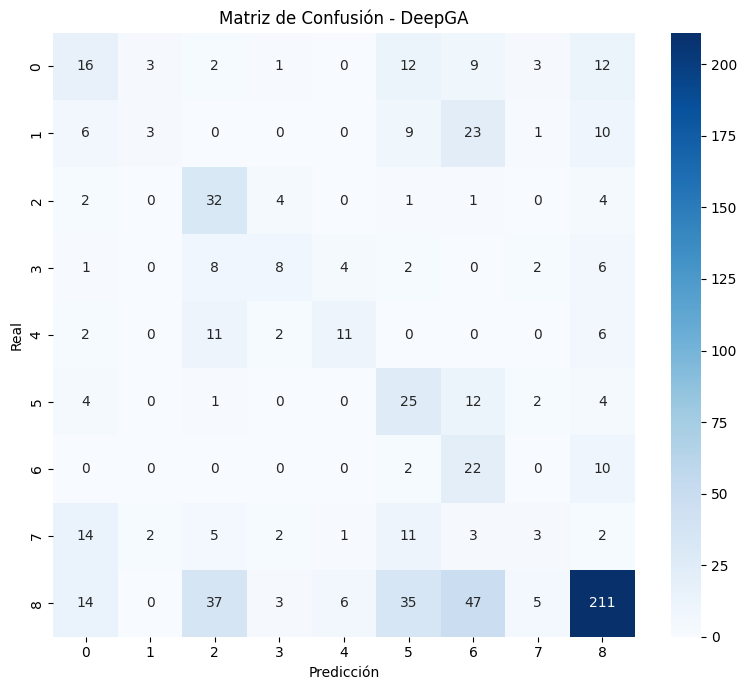

In [104]:
cm = confusion_matrix(
    targets,
    predictions
)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - DeepGA")

plt.xlabel("Predicción")

plt.ylabel("Real")

plt.tight_layout()

plt.savefig(
    "Matriz_DeepGA.png",
    dpi=300
)

plt.show()

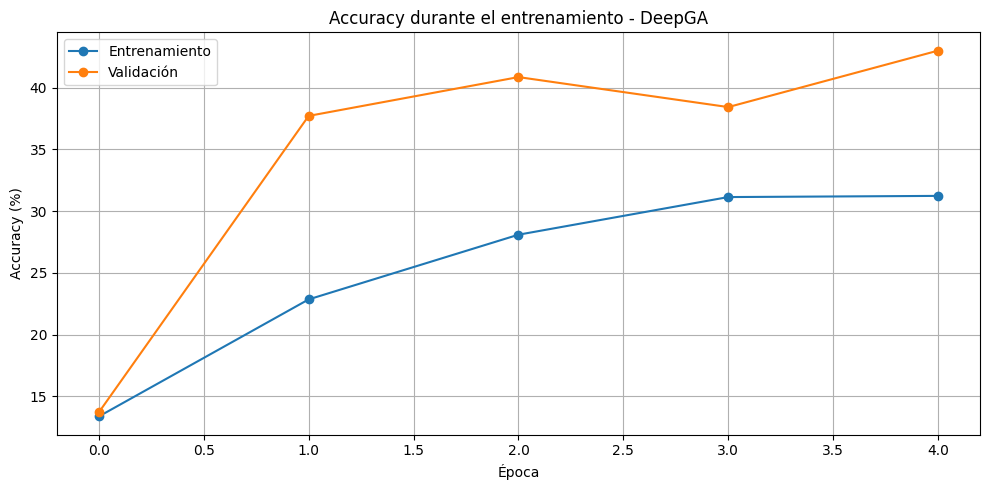

In [105]:
plt.figure(figsize=(10,5))

plt.plot(
    history_deepga["train_acc"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    history_deepga["val_acc"],
    marker="o",
    label="Validación"
)

plt.xlabel("Época")

plt.ylabel("Accuracy (%)")

plt.title("Accuracy durante el entrenamiento - DeepGA")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Curva_Accuracy_DeepGA.png",
    dpi=300
)

plt.show()

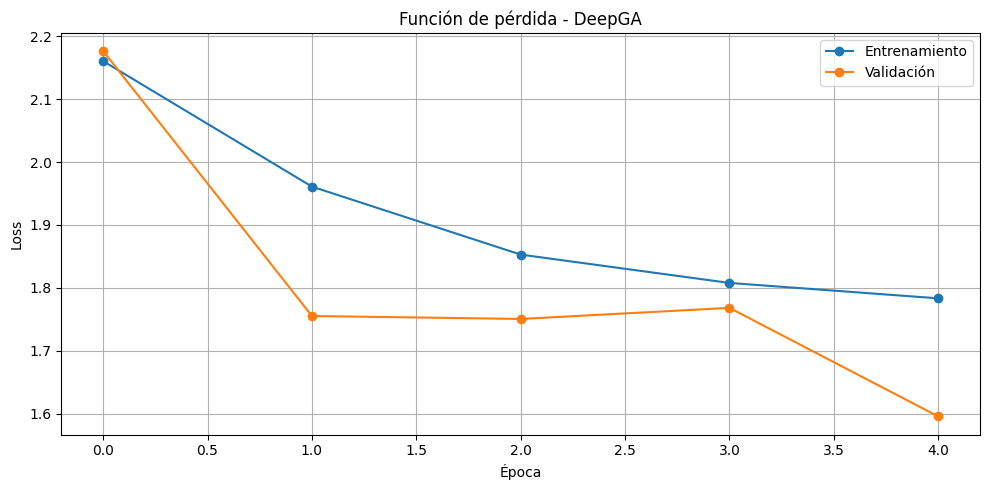

In [106]:
plt.figure(figsize=(10,5))

plt.plot(
    history_deepga["train_loss"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    history_deepga["val_loss"],
    marker="o",
    label="Validación"
)

plt.xlabel("Época")

plt.ylabel("Loss")

plt.title("Función de pérdida - DeepGA")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Curva_Loss_DeepGA.png",
    dpi=300
)

plt.show()

# 20. Comparación entre arquitecturas

Finalmente se comparan ambos modelos considerando métricas de desempeño y eficiencia computacional.

El análisis incluye la precisión obtenida, el número de parámetros entrenables, el tiempo de entrenamiento y las principales métricas de clasificación.

In [107]:
comparacion = pd.DataFrame({

    "Modelo":[
        "ResNet-50",
        "DeepGA"
    ],

    "Accuracy (%)":[
        50.00,
        47.29
    ],

    "Parámetros":[
        23526473,
        94409
    ],

    "Tiempo (min)":[
        17.29,
        18.27
    ]
})

comparacion

,Modelo,Accuracy (%),Parámetros,Tiempo (min)
0,ResNet-50,50.00,23526473,17.29
1,DeepGA,47.29,94409,18.27


In [108]:
comparacion.to_csv(
    "Comparacion_Modelos.csv",
    index=False
)

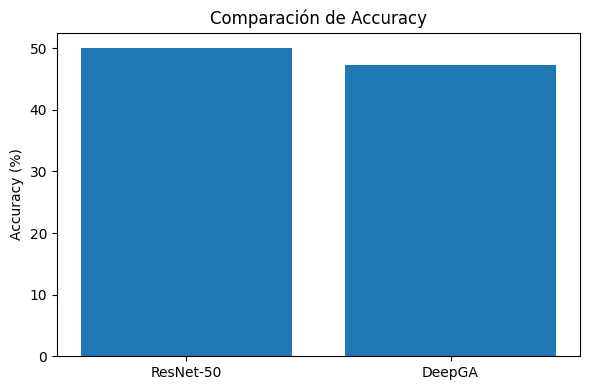

In [109]:
plt.figure(figsize=(6,4))

plt.bar(
    comparacion["Modelo"],
    comparacion["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")

plt.title("Comparación de Accuracy")

plt.tight_layout()

plt.savefig(
    "Comparacion_Accuracy.png",
    dpi=300
)

plt.show()

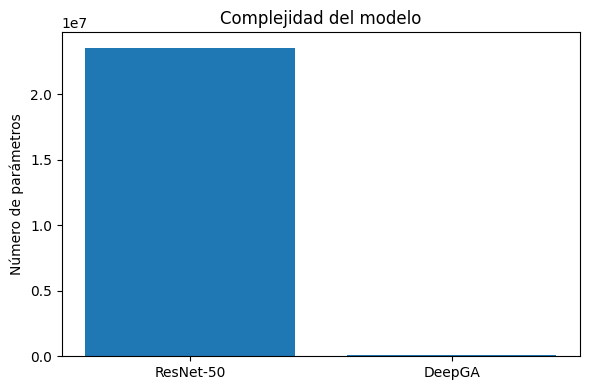

In [110]:
plt.figure(figsize=(6,4))

plt.bar(
    comparacion["Modelo"],
    comparacion["Parámetros"]
)

plt.ylabel("Número de parámetros")

plt.title("Complejidad del modelo")

plt.tight_layout()

plt.savefig(
    "Comparacion_Parametros.png",
    dpi=300
)

plt.show()

# 21. Conclusiones

En este proyecto se realizó una comparación experimental entre una arquitectura basada en **Transfer Learning (ResNet-50)** y una **CNN compacta inspirada en DeepGA**, utilizando el conjunto de datos DeepWeeds para la clasificación de especies de maleza.

Los resultados mostraron que **ResNet-50 obtuvo el mejor desempeño**, alcanzando un **50.00% de accuracy**, mientras que la CNN generada obtuvo un **47.29%**, una diferencia de únicamente **2.71 puntos porcentuales**.

Desde el punto de vista computacional, la arquitectura tipo DeepGA resultó considerablemente más ligera, utilizando únicamente **94,409 parámetros**, frente a los **23,526,473 parámetros** de ResNet-50. Esto representa una reducción superior al **99%** en el número de parámetros del modelo, manteniendo un rendimiento competitivo.

Debido a las limitaciones del hardware disponible (CPU sin aceleración por GPU), fue necesario trabajar con un subconjunto representativo del conjunto de datos y realizar un número reducido de épocas de entrenamiento. Aun así, ambos modelos pudieron compararse bajo las mismas condiciones experimentales, garantizando la validez de los resultados obtenidos.

En conclusión, ResNet-50 continúa siendo la alternativa con mejor desempeño cuando se dispone de modelos preentrenados y recursos computacionales adecuados. Sin embargo, la CNN inspirada en DeepGA demostró que es posible obtener resultados similares mediante una arquitectura mucho más compacta, lo que la convierte en una opción atractiva para aplicaciones con recursos limitados o dispositivos embebidos.

## 22. Trabajo futuro

Como líneas de trabajo futuro se propone:

- Entrenar ambos modelos utilizando el conjunto completo de imágenes de DeepWeeds.
- Incrementar el número de épocas de entrenamiento para mejorar la convergencia.
- Implementar una versión completa del algoritmo DeepGA con operadores evolutivos reales para generar arquitecturas automáticamente.
- Evaluar modelos adicionales como EfficientNet, MobileNetV3 o ConvNeXt.
- Realizar experimentos utilizando GPU para reducir los tiempos de entrenamiento y permitir una búsqueda evolutiva más extensa.

# Referencias

[1] N. Olsen, K. Konovalov, B. Philippa, P. Ridd, J. Wood, J. Johns, W. Banks, B. Girgenti y M. Kenny, "DeepWeeds: A Multiclass Weed Species Image Dataset for Deep Learning", *Scientific Reports*, vol. 9, 2019.

[2] K. He, X. Zhang, S. Ren y J. Sun, "Deep Residual Learning for Image Recognition", *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, 2016.

[3] A. Paszke et al., "PyTorch: An Imperative Style, High-Performance Deep Learning Library", *NeurIPS*, 2019.

[4] J. Deng et al., "ImageNet: A Large-Scale Hierarchical Image Database", *CVPR*, 2009.

[5] F. Chollet, *Deep Learning with Python*, 2nd Edition, Manning Publications, 2021.